In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nicksri1248/ushape-dataset/ushape.csv", header=None, names=['X', 'Y', 'class'])

In [3]:
df['X'] = df['X'].round(4)
df['Y'] = df['Y'].round(4)

In [4]:
df.head()

,X,Y,class
0,0.0316,0.9870,0.0
1,2.1151,-0.0462,1.0
2,0.8825,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8295,-0.5393,1.0


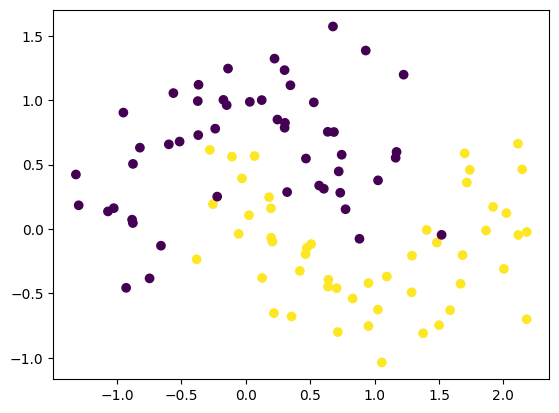

In [5]:
plt.scatter(df['X'], df['Y'], c = df['class'])

In [6]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

In [7]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

2026-06-08 18:43:28.995866: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780944209.217366      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780944209.279076      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780944209.819838      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780944209.819906      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780944209.819908      58 computation_placer.cc:177] computation placer alr

# Xavier Weight Initialization

In [8]:
model = Sequential()

model.add(Dense(10, activation = 'tanh', input_dim = 2))
model.add(Dense(10, activation = 'tanh'))
model.add(Dense(10, activation = 'tanh'))
model.add(Dense(10, activation = 'tanh'))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-08 18:43:44.624955: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.get_weights()

[array([[-0.01232427,  0.2555766 , -0.36057842,  0.69274217,  0.18834347,
          0.04307878, -0.01501977, -0.14215708, -0.0242095 ,  0.2871114 ],
        [-0.6569419 ,  0.140948  ,  0.25319296,  0.35634118, -0.48545784,
          0.21558046, -0.5313244 , -0.16996223, -0.15392584,  0.4885158 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.24922407, -0.25609556,  0.44698316, -0.06957376, -0.53114665,
          0.47454274, -0.14293048,  0.14914215,  0.00519526, -0.30712736],
        [-0.36279774,  0.15335667,  0.0938549 ,  0.00612766, -0.44311097,
         -0.38797703, -0.5295062 , -0.5205154 ,  0.4718045 , -0.25703788],
        [ 0.21202314, -0.4082187 , -0.25470492,  0.44120312, -0.05977055,
          0.45570338, -0.24984083,  0.02309877, -0.47724754,  0.38236868],
        [-0.29906893, -0.04719591, -0.24557465,  0.13357157, -0.17979226,
         -0.09942311, -0.2902701 ,  0.1441921 ,  0.43633074, -0.01450586],
        [ 0.01477

In [10]:
initial_weights = model.get_weights()

In [11]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [12]:
model.set_weights(initial_weights)

In [13]:
model.get_weights()

[array([[ 0.7102347 , -1.1590301 , -0.39613575, -0.3678253 , -0.7050662 ,
          0.2133547 , -0.5112267 , -0.15621193,  0.21344411, -0.9852322 ],
        [ 0.02073252, -0.9960051 , -0.7533696 , -0.9268842 ,  0.60643834,
         -0.38539922, -0.37003285, -0.01500009,  0.48349053,  1.3126174 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.03277871,  0.18349957,  0.14887635,  0.10486028, -0.2149544 ,
         -0.14807466,  0.18648319,  0.09505382,  0.26081395, -0.14329916],
        [-0.01743236, -0.20419745, -0.00897406, -0.58636075, -0.16208671,
          0.6901392 , -0.13083734, -0.22135733,  0.0738728 ,  0.10954916],
        [ 0.26538366, -0.623295  ,  0.10146931, -0.09995718, -0.53191036,
         -0.51714647,  0.0308912 , -0.40309614, -0.0012853 , -0.06205485],
        [ 0.19242506, -0.33456933,  0.43650094,  0.11619435, -0.14367175,
          0.23952095,  0.04673472,  0.35489503, -0.08509623,  0.6352971 ],
        [ 0.11389

In [14]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [15]:
history = model.fit(X, y, epochs = 100, validation_split = 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.4250 - loss: 0.6908 - val_accuracy: 0.4500 - val_loss: 0.6901
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6250 - loss: 0.6812 - val_accuracy: 0.7500 - val_loss: 0.6781
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7875 - loss: 0.6719 - val_accuracy: 0.8500 - val_loss: 0.6669
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8500 - loss: 0.6633 - val_accuracy: 0.9000 - val_loss: 0.6557
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8500 - loss: 0.6550 - val_accuracy: 0.9000 - val_loss: 0.6446
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8500 - loss: 0.6465 - val_accuracy: 0.8500 - val_loss: 0.6337
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8500 - loss: 0.6387 - val_accuracy: 0.8500 - val_loss: 0.6229
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8375 - loss: 0.6303 - val_accuracy: 0.8500 - val_loss:

In [16]:
model.get_weights()

[array([[ 0.66613984, -1.1796893 , -0.35910472, -0.2687755 , -0.59684914,
          0.312667  , -0.5603796 , -0.13722518,  0.30202788, -0.85193133],
        [-0.0250535 , -0.96553874, -0.86547947, -0.99338603,  0.652337  ,
         -0.47649676, -0.32342985, -0.09897431,  0.34943828,  1.4438815 ]],
       dtype=float32),
 array([ 0.08794845,  0.2829629 ,  0.02520258,  0.07432688,  0.09524139,
        -0.01806751, -0.09462537,  0.00923364, -0.08655202,  0.15552676],
       dtype=float32),
 array([[ 0.10310687,  0.26691508,  0.2267865 , -0.03203155, -0.20648625,
         -0.07836076,  0.14109176,  0.0196283 ,  0.31298524, -0.06198436],
        [-0.03813408, -0.25462213,  0.02145843, -0.56706387, -0.30956364,
          0.5156516 , -0.20154656, -0.29334304,  0.16318114,  0.14658146],
        [ 0.2943039 , -0.63622826,  0.14521661, -0.12513897, -0.5966127 ,
         -0.6317502 , -0.05295207, -0.4837116 ,  0.08286224, -0.01795786],
        [ 0.25393617, -0.3120032 ,  0.5057261 ,  0.06440432, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

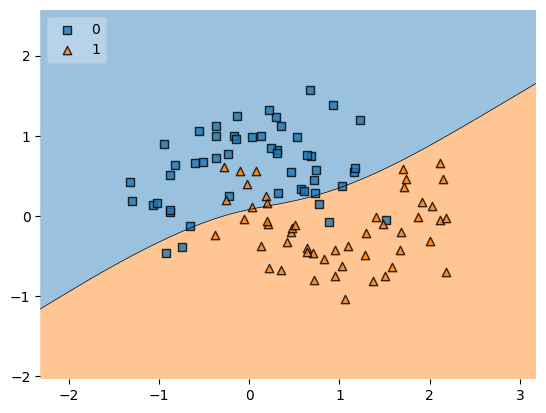

In [17]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf = model, legend = 2)

## Keras Implementation

In [18]:
model = Sequential()

model.add(Dense(10, activation = 'relu', input_dim = 2, kernel_initializer = 'he_normal'))
# he_uniform || glorat_normal || glorat_uniform(default)
model.add(Dense(10, activation = 'relu', kernel_initializer = 'he_normal'))
model.add(Dense(10, activation = 'relu', kernel_initializer = 'he_normal'))
model.add(Dense(10, activation = 'relu', kernel_initializer = 'he_normal'))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.get_weights()

[array([[-0.4617125 , -2.064335  , -1.6871892 ,  0.79838336, -0.21654154,
          1.0637871 ,  0.83689004,  0.94128096,  0.37971848, -0.18521239],
        [-0.22975805,  0.58607244, -0.36927515, -0.9801011 , -0.23941702,
          0.14125499, -2.2526197 , -2.1211941 ,  0.48727357,  2.1666708 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.41969138, -0.99280554, -0.15363601, -0.3436653 , -0.51440775,
         -0.02382965,  0.06437385,  0.56167644, -0.10490698, -0.3394387 ],
        [-0.27420747, -0.0254495 ,  0.60766894,  0.81475997, -0.93322915,
          0.2916172 , -0.8602887 , -0.00671772,  0.24860972,  0.73498845],
        [ 0.26293772,  0.07834353, -0.7058735 ,  0.10273647, -0.22803529,
         -0.7635339 ,  0.30819446,  0.86827374, -0.2233356 , -0.02283389],
        [ 0.1902061 , -0.18498018, -0.26317286,  0.28236902, -0.51596713,
          0.16266878,  0.03924726,  0.15588948,  0.39957115,  0.19497617],
        [-0.53164

In [20]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [21]:
history = model.fit(X, y, epochs = 100, validation_split = 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.5000 - loss: 0.6385 - val_accuracy: 0.4500 - val_loss: 0.6406
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5125 - loss: 0.6271 - val_accuracy: 0.5500 - val_loss: 0.6275
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5375 - loss: 0.6161 - val_accuracy: 0.6000 - val_loss: 0.6147
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6750 - loss: 0.6061 - val_accuracy: 0.6500 - val_loss: 0.6028
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7500 - loss: 0.5956 - val_accuracy: 0.6500 - val_loss: 0.5924
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7875 - loss: 0.5860 - val_accuracy: 0.7000 - val_loss: 0.5827
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8000 - loss: 0.5758 - val_accuracy: 0.8000 - val_loss: 0.5735
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8000 - loss: 0.5661 - val_accuracy: 0.8000 - val_loss

In [22]:
model.get_weights()

[array([[-0.4133455 , -2.0416036 , -1.5326308 ,  0.98773265, -0.35908604,
          1.0866357 ,  0.90001386,  1.0300342 ,  0.4146147 , -0.09617372],
        [-0.25623363,  0.50535077, -0.42140484, -0.77154386, -0.03727235,
          0.12758909, -2.2308335 , -2.2221036 ,  0.5475445 ,  2.332227  ]],
       dtype=float32),
 array([-0.06314811, -0.0591323 ,  0.00806333,  0.14827198, -0.07673832,
         0.10069476, -0.01864182,  0.06645647,  0.10487521, -0.01194848],
       dtype=float32),
 array([[-0.45319644, -0.94037515, -0.09433228, -0.41882643, -0.45697048,
          0.0427988 ,  0.00707669,  0.47328174, -0.07603071, -0.27478594],
        [-0.22832033,  0.0565643 ,  0.5504622 ,  0.7283474 , -0.8952846 ,
          0.4045778 , -1.0079004 , -0.10884939,  0.22963218,  0.71765345],
        [ 0.24690807,  0.17065339, -0.7224957 ,  0.01631426, -0.13612115,
         -0.6330935 ,  0.15621978,  0.77509844, -0.17579776,  0.0092333 ],
        [ 0.2690396 , -0.11845467, -0.27248716,  0.39512774, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: >

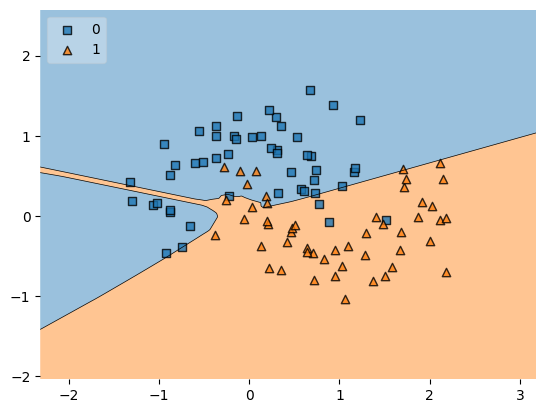

In [23]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf = model, legend = 2)